# PHẦN 2: THUẬT TOÁN FLAJOLET-MARTIN CƠ BẢN (1 HASH FUNCTION)
## Chuyên đề Xử Lý Dữ Liệu Lớn - Giảng viên: Trần Thị Nhi

### 1. Cơ sở lý thuyết
- **Tác giả & Năm công bố:** Philippe Flajolet và G. Nigel Martin (1985).
- **Ý tưởng cốt lõi:**
  1. Mỗi phần tử $x$ trong luồng được đưa qua một hàm băm đồng nhất $h(x)$, ánh xạ thành số nguyên nhị phân 32-bit.
  2. Đếm số lượng bit 0 tận cùng liên tiếp ở cuối chuỗi nhị phân (gọi là hàm $\rho(h(x))$).
  3. Xác suất để một giá trị ngẫu nhiên có $k$ bit 0 liên tiếp ở cuối là $2^{-(k+1)}$ (tương tự việc tung đồng xu liên tiếp ra mặt sấp).
  4. Đại lượng $R = \max(\rho)$ (số bit 0 liên tiếp lớn nhất ghi nhận được) là ước lượng tỷ lệ thuận với $\log_2 n$.
- **Hằng số hiệu chỉnh $\phi$:**
  - Ước lượng thô ban đầu $2^R$ có độ lệch hệ thống (bias).
  - Bằng phép biến đổi giải tích phức Mellin, Flajolet và Martin chứng minh được $\mathbb{E}[2^R] \approx \phi \cdot n$ với:
    $$\phi \approx 0.77351$$
  - Công thức ước lượng không chệch (unbiased estimator):
    $$\hat{n} = \frac{2^R}{\phi} \approx 1.29281 \times 2^R$$
- **Đặc tính kỹ thuật:**
  - **Thời gian:** $O(1)$ mỗi phần tử (1 lần băm và thao tác bit).
  - **Bộ nhớ:** $O(1)$ - Cực kỳ nhỏ gọn, chỉ cần duy trì đúng một biến số nguyên $R$ (vài chục bytes).
  - **Nhược điểm:** Sai số chuẩn rất lớn $\sigma(R) \approx 1.12$ bits, tương ứng sai số tương đối lên tới $\approx 78\%$, kết quả ước lượng thường tăng nhảy bậc theo lũy thừa của 2.

In [1]:
# 0. Tự động kiểm tra và Mount Google Drive (chỉ kích hoạt khi chạy trên Google Colab)
try:
    from google.colab import drive
    import os
    if not os.path.exists('/content/drive'):
        print("Đang kết nối tới Google Drive...")
        drive.mount('/content/drive')
    else:
        print("Google Drive đã được kết nối sẵn!")
except ImportError:
    print("Đang chạy trên môi trường Local (không phải Google Colab), bỏ qua mount Drive.")

Google Drive đã được kết nối sẵn!


In [2]:
# 1. Khởi tạo và nạp các thư viện cần thiết
import os
import sys
import time
import json
import hashlib
import tracemalloc
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
print("Đã nạp xong thư viện thành công!")

Đã nạp xong thư viện thành công!


In [3]:
# 2. Cấu hình đường dẫn dữ liệu (Hỗ trợ cả Local và Google Colab)
def get_log_file_path():
    candidates = [
        "accessLog/access.log",
        "/content/drive/MyDrive/accessLog/access.log",
        "../accessLog/access.log",
        "access.log"
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return "accessLog/access.log"

LOG_FILE = get_log_file_path()
print(f"Đường dẫn file log: {LOG_FILE}")

Đường dẫn file log: /content/drive/MyDrive/accessLog/access.log


In [4]:
# 3. Định nghĩa các hàm băm và thao tác bit toán học
def count_trailing_zeros(n):
    """
    Đếm số lượng bit 0 liên tiếp ở tận cùng chuỗi nhị phân của số nguyên n.
    Sử dụng toán tử bit-shift để đạt tốc độ tối đa.
    """
    if n == 0:
        return 32  # Giới hạn 32-bit
    zeros = 0
    while (n & 1) == 0:
        zeros += 1
        n >>= 1
    return zeros

def hash_function(data_str, seed=42):
    """
    Tạo ra hàm băm đồng nhất bằng cách băm chuỗi 'seed_data' qua MD5.
    Trả về số nguyên 32-bit không âm.
    """
    salted_input = f"{seed}_{data_str}".encode('utf-8')
    hash_digest = hashlib.md5(salted_input).hexdigest()
    return int(hash_digest[:8], 16)

print("Đã định nghĩa xong hàm băm và đếm bit 0!")

Đã định nghĩa xong hàm băm và đếm bit 0!


In [5]:
# 4. Cài đặt lớp Thuật toán Flajolet-Martin Cơ bản (1 Hash)
class FlajoletMartinBasic:
    """
    Thuật toán Flajolet-Martin cơ bản (Sử dụng 1 hàm băm)
    """
    def __init__(self, seed=42):
        self.seed = seed
        self.max_zeros = 0
        self.phi = 0.77351  # Hằng số hiệu chỉnh Flajolet-Martin

    def update(self, item):
        """Cập nhật khi có phần tử mới đi qua luồng"""
        hash_val = hash_function(item, self.seed)
        r = count_trailing_zeros(hash_val)
        if r > self.max_zeros:
            self.max_zeros = r

    def estimate(self):
        """Tính toán số lượng phần tử duy nhất ước lượng"""
        return (2 ** self.max_zeros) / self.phi

print("Đã cài đặt xong lớp FlajoletMartinBasic!")

Đã cài đặt xong lớp FlajoletMartinBasic!


In [6]:
# 5. Hàm đọc luồng dữ liệu (Streaming Generator)
def stream_log_file(file_path):
    if not os.path.exists(file_path):
        print(f"[CẢNH BÁO] Không tìm thấy file: {file_path}")
        return
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line:
                yield line.split(' ', 1)[0]

In [7]:
# 6. Hàm thực nghiệm Flajolet-Martin Cơ bản
def run_fm_basic_experiment(log_file_path, sample_step=50000, max_lines=None):
    fm_basic = FlajoletMartinBasic(seed=42)
    stream_counts = []
    estimates_history = []
    max_zeros_history = []

    # Nạp ground truth từ set_metrics.json nếu có để đo sai số
    exact_lookup = {}
    if os.path.exists('results/set_metrics.json'):
        with open('results/set_metrics.json', 'r', encoding='utf-8') as f:
            set_data = json.load(f)
            for s, u in zip(set_data.get('history_steps', []), set_data.get('history_unique', [])):
                exact_lookup[s] = u

    print("="*70)
    print("BẮT ĐẦU THỰC NGHIỆM FLAJOLET-MARTIN CƠ BẢN (1 HASH)")
    print(f"File: {log_file_path} | Sample step: {sample_step:,} dòng")
    print("="*70)

    tracemalloc.start()
    start_time = time.time()
    total_processed = 0

    for ip in stream_log_file(log_file_path):
        total_processed += 1
        fm_basic.update(ip)

        if total_processed % sample_step == 0:
            est = fm_basic.estimate()
            stream_counts.append(total_processed)
            estimates_history.append(est)
            max_zeros_history.append(fm_basic.max_zeros)

            exact_str = f"{exact_lookup[total_processed]:,}" if total_processed in exact_lookup else "Chưa có"
            print(f"Dòng: {total_processed:>10,} | Bit 0 max (R): {fm_basic.max_zeros:>2} | Ước lượng FM: {int(est):>10,} | Thực tế: {exact_str}")

        if max_lines and total_processed >= max_lines:
            break

    elapsed_time = time.time() - start_time
    _, peak_ram = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    final_estimate = fm_basic.estimate()
    fm_bytes = sys.getsizeof(fm_basic) + sys.getsizeof(fm_basic.max_zeros)

    print("\n" + "="*70)
    print("KẾT QUẢ TỔNG KẾT (FM 1 HASH):")
    print(f"- Tổng số dòng log đã quét:            {total_processed:,}")
    print(f"- Số bit 0 tận cùng lớn nhất (R):      {fm_basic.max_zeros}")
    print(f"- Số IP ước lượng (2^R / phi):         {int(final_estimate):,}")
    print(f"- Thời gian thực thi:                  {elapsed_time:.2f} giây")
    print(f"- Dung lượng cấu trúc FM chiếm dụng:   {fm_bytes} Bytes ({fm_bytes/1024:.2f} KB)")
    print(f"- Peak RAM hệ thống:                   {peak_ram / (1024*1024):.4f} MB")
    print("="*70)

    # Lưu kết quả sang results/fm_basic_metrics.json
    os.makedirs('results', exist_ok=True)
    results_data = {
        "method": "Flajolet-Martin Basic (1 Hash)",
        "total_processed": total_processed,
        "max_zeros": fm_basic.max_zeros,
        "estimate_final": round(final_estimate, 2),
        "elapsed_time": round(elapsed_time, 2),
        "fm_bytes": fm_bytes,
        "peak_ram_bytes": peak_ram,
        "history_steps": stream_counts,
        "history_estimates": [round(e, 2) for e in estimates_history],
        "history_max_zeros": max_zeros_history
    }
    with open('results/fm_basic_metrics.json', 'w', encoding='utf-8') as f:
        json.dump(results_data, f, indent=2, ensure_ascii=False)
    print("-> Đã lưu kết quả thành công vào 'results/fm_basic_metrics.json'!")

    return stream_counts, estimates_history, max_zeros_history

In [8]:
# 7. Chạy thực nghiệm
steps, estimates, r_values = run_fm_basic_experiment(LOG_FILE, sample_step=50000)

BẮT ĐẦU THỰC NGHIỆM FLAJOLET-MARTIN CƠ BẢN (1 HASH)
File: /content/drive/MyDrive/accessLog/access.log | Sample step: 50,000 dòng
Dòng:     50,000 | Bit 0 max (R): 11 | Ước lượng FM:      2,647 | Thực tế: 2,179
Dòng:    100,000 | Bit 0 max (R): 11 | Ước lượng FM:      2,647 | Thực tế: 3,987
Dòng:    150,000 | Bit 0 max (R): 11 | Ước lượng FM:      2,647 | Thực tế: 5,346
Dòng:    200,000 | Bit 0 max (R): 11 | Ước lượng FM:      2,647 | Thực tế: 6,510
Dòng:    250,000 | Bit 0 max (R): 12 | Ước lượng FM:      5,295 | Thực tế: 7,616
Dòng:    300,000 | Bit 0 max (R): 12 | Ước lượng FM:      5,295 | Thực tế: 8,694
Dòng:    350,000 | Bit 0 max (R): 12 | Ước lượng FM:      5,295 | Thực tế: 9,685
Dòng:    400,000 | Bit 0 max (R): 12 | Ước lượng FM:      5,295 | Thực tế: 10,653
Dòng:    450,000 | Bit 0 max (R): 12 | Ước lượng FM:      5,295 | Thực tế: 11,676
Dòng:    500,000 | Bit 0 max (R): 12 | Ước lượng FM:      5,295 | Thực tế: 12,669
Dòng:    550,000 | Bit 0 max (R): 12 | Ước lượng FM:      

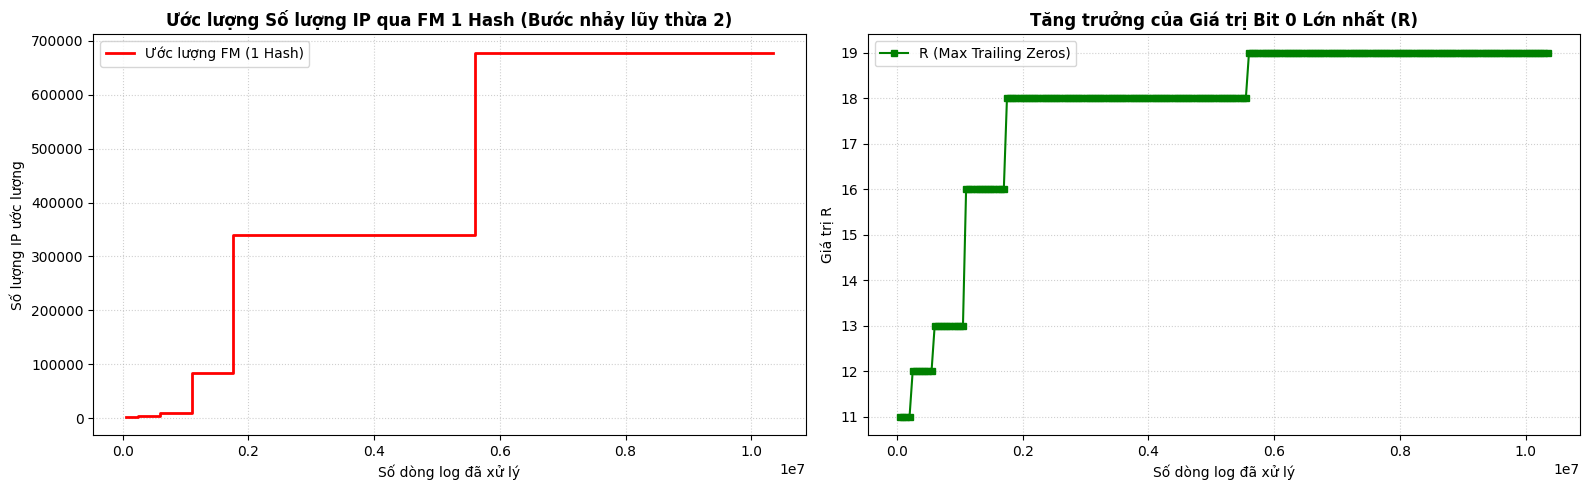

In [9]:
# 8. Trực quan hóa kết quả FM Cơ bản
if steps:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Đồ thị 1: Đường ước lượng FM dạng bậc thang
    ax1.step(steps, estimates, 'r-', where='post', linewidth=2, label='Ước lượng FM (1 Hash)')
    ax1.set_title('Ước lượng Số lượng IP qua FM 1 Hash (Bước nhảy lũy thừa 2)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Số dòng log đã xử lý')
    ax1.set_ylabel('Số lượng IP ước lượng')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # Đồ thị 2: Diễn biến của chỉ số R (max bit 0)
    ax2.plot(steps, r_values, 'g-s', markersize=4, label='R (Max Trailing Zeros)')
    ax2.set_title('Tăng trưởng của Giá trị Bit 0 Lớn nhất (R)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Số dòng log đã xử lý')
    ax2.set_ylabel('Giá trị R')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

### 9. Nhận xét và Phân tích Thuật toán FM Cơ bản
- **Hiệu quả bộ nhớ:** Cực kỳ vượt trội! Thuật toán chỉ tốn chưa tới $100$ Bytes bộ nhớ để theo dõi luồng hàng triệu IP, tiết kiệm gấp hàng chục ngàn lần so với cấu trúc `Set`.
- **Hạn chế lớn về độ mượt mà:** Do chỉ có một hàm băm, ước lượng $\hat{n} = 2^R / \phi$ chỉ có thể nhận các giá trị rời rạc (nhảy vọt gấp đôi mỗi khi tìm thấy một giá trị hash có thêm 1 bit 0). Điều này tạo ra đồ thị dạng bậc thang với độ lệch chuẩn rất cao (sai số lý thuyết $\approx 78\%$).
- **Hướng giải quyết:** Cần áp dụng kỹ thuật **Multi-Hash kết hợp Median of Means** (sẽ được cài đặt ở Notebook 3) để làm phẳng đường ước lượng và thu hẹp sai số.